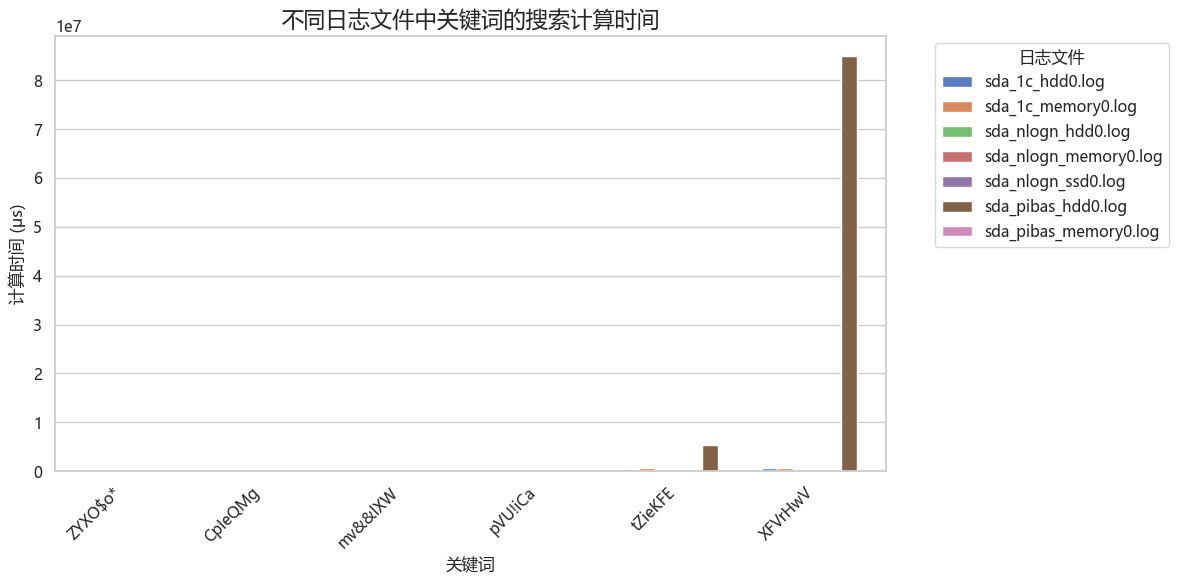

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from pathlib import Path
import re

# 设置绘图样式（高级配色、模仿顶刊格式）
sns.set_theme(style="whitegrid", palette="muted")

# 设置中文字体，避免中文标题/坐标轴在 Matplotlib 中显示为方框或触发 glyph warning
font_candidates = ['Microsoft YaHei', 'SimHei', 'SimSun', 'Noto Sans CJK SC', 'WenQuanYi Micro Hei']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
plt.rcParams['axes.unicode_minus'] = False

# 读取日志文件的目录
log_dir = Path('./data')
if not log_dir.exists():
    log_dir = Path('科研绘图/data')
log_files = [
    'sda_1c_hdd0.log', 'sda_1c_memory0.log', 'sda_nlogn_hdd0.log',
    'sda_nlogn_memory0.log', 'sda_nlogn_ssd0.log', 'sda_pibas_hdd0.log', 'sda_pibas_memory0.log'
]

# 定义解析日志文件的函数
def parse_log(file_name):
    file_path = log_dir / file_name
    # 打开文件并读取所有行
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # 日志中关键词和搜索耗时分布在相邻两行，按状态解析
    data = []
    current_keyword = None
    search_pattern = re.compile(r'Search for Keyword\s+(.+?)\s+with result size=\d+')
    time_pattern = re.compile(r'Total Search Computation Time \(microseconds\):\s*([0-9.eE+-]+)')
    for line in lines:
        search_match = search_pattern.search(line)
        if search_match:
            current_keyword = search_match.group(1).strip()
            continue

        time_match = time_pattern.search(line)
        if time_match and current_keyword is not None:
            time = float(time_match.group(1))
            data.append([file_name, current_keyword, time])
            current_keyword = None

    return pd.DataFrame(data, columns=['文件', '关键词', '时间 (μs)'])

# 将所有日志文件的数据合并为一个DataFrame
all_data = pd.concat([parse_log(file) for file in log_files], ignore_index=True)
if all_data.empty:
    raise ValueError('未从日志文件中解析到数据，请检查 log_dir、log_files 和日志格式。')

# 创建透视表，方便绘制图表
pivot_data = all_data.pivot_table(index=['文件', '关键词'], values='时间 (μs)', aggfunc='mean')

# 绘图
fig, ax = plt.subplots(figsize=(12, 6))

# 创建柱状图
sns.barplot(x='关键词', y='时间 (μs)', hue='文件', data=all_data, errorbar=None, ax=ax)

# 设置中文标签和标题
ax.set_title('不同日志文件中关键词的搜索计算时间', fontsize=16)
ax.set_xlabel('关键词', fontsize=12)
ax.set_ylabel('计算时间 (μs)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(title='日志文件', bbox_to_anchor=(1.05, 1), loc='upper left')

# 调整布局，避免标题和标签被裁剪
plt.tight_layout()

# 保存图像
plt.savefig('计算时间关键词.png', dpi=300, bbox_inches='tight')

# 显示图像
plt.show()